In [1]:
import pandas as pd

In [2]:
import torch
from torch import nn, optim

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

In [4]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [5]:
import random

In [6]:
import numpy as np

In [7]:
import matplotlib.pyplot as plot

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
from string import punctuation

In [10]:
df = pd.read_csv("D:/git/dados/nlp/imdb-reviews-pt-br.csv", encoding="utf-8")

In [11]:
df = df[["text_pt"]]
df

,text_pt
0,"Mais uma vez, o Sr. Costner arrumou um filme p..."
1,Este é um exemplo do motivo pelo qual a maiori...
2,"Primeiro de tudo eu odeio esses raps imbecis, ..."
3,Nem mesmo os Beatles puderam escrever músicas ...
4,Filmes de fotos de latão não é uma palavra apr...
...,...
49454,"Como a média de votos era muito baixa, e o fat..."
49455,O enredo teve algumas reviravoltas infelizes e...
49456,Estou espantado com a forma como este filme e ...
49457,A Christmas Together realmente veio antes do m...


In [12]:
MAX_PALAVRAS_FRASE = 30

In [13]:
TABLE_LIMPAR = str.maketrans("", "", "\u200b" + "\u000b" + punctuation)
def limpar( texto ):
    return texto.lower().translate(TABLE_LIMPAR)

In [14]:
frases_limpas = df["text_pt"].apply(limpar)

In [15]:
frases_selecionadas = frases_limpas[0:1000]

In [16]:
frases_selecionadas[10]

'cage interpreta um bêbado e é elogiado pela crítica elizabeth shue na verdade tem que fazer um amor com a parte mais desprezível e superestimada de estrume em hollywood eu literalmente vomitei enquanto assistia a esse filme claro que tive gripe mas isso não significa que este filme não tenha contribuído para o vômito no kamode por que nick cage não pode tocar em algo que ele pode realmente fazer como um ator ruim nick cage que é brilhante em um papel de mau ator parreira ninguém poderia fazer melhor a busca começa por nicks contrato com lúcifer ou lou cipher de night train to terror'

In [17]:
dicionario = { 
    "<UNKNOWN>": 0,
    "<PAD>": 1
}

In [18]:
contador_palavras = len(dicionario.keys())
lista_frases_numeros = [ ]
for frase in frases_selecionadas:
    lista_tokens_numericos = []
    for idx, token in enumerate(frase.split(" ")):
        if token in dicionario:
            numero = dicionario[token]
        else:
            numero = contador_palavras
            dicionario[token] = numero
            contador_palavras += 1
        lista_tokens_numericos.append( numero )
        if idx >= MAX_PALAVRAS_FRASE:
            break
    lista_frases_numeros.append( lista_tokens_numericos )

In [20]:
print(lista_frases_numeros[0])
print(lista_frases_numeros[1])
print(lista_frases_numeros[2])
print(lista_frases_numeros[3])
print(lista_frases_numeros[4])

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 2, 13, 14, 15, 5, 16, 17, 18, 19, 20, 21, 22, 23, 24, 18, 25, 26, 12, 27, 28]
[29, 30, 9, 31, 14, 32, 33, 34, 35, 36, 37, 38, 21, 39, 40, 41, 42, 43, 44, 45, 46, 26, 47, 15, 48, 35, 49, 50, 51, 9, 52]
[53, 21, 54, 28, 55, 56, 57, 58, 15, 46, 59, 60, 61, 62, 3, 63, 64, 65, 66, 67, 54, 5, 15, 68, 69, 30, 70, 44, 71, 9, 23]
[72, 73, 41, 74, 75, 76, 77, 15, 78, 79, 44, 80, 81, 82, 46, 83, 9, 84, 85, 30, 86, 87, 61, 88, 21, 38, 21, 39, 89, 41, 90]
[38, 21, 91, 21, 92, 46, 30, 3, 93, 94, 95, 68, 96, 97, 40, 9, 98, 99, 66, 100, 101, 102, 40, 103, 21, 104, 21, 105, 106, 21, 107]


In [21]:
print(len(dicionario))

5827


In [22]:
dicionario_reverso = {}
for chave in dicionario.keys():
    valor = dicionario[chave]
    dicionario_reverso[valor] = chave

In [23]:
print("Numero da palavra Filme: ", dicionario["filme"])
print("Palavra do numero 10: ", dicionario_reverso[10])

Numero da palavra Filme:  10
Palavra do numero 10:  filme


In [24]:
X_draft = []
Y_draft = []
for frase_numeros in lista_frases_numeros:
    for i in range(2, len(frase_numeros)):
        features = frase_numeros[0:i]
        label = frase_numeros[i]
        palavra = dicionario_reverso[label]
        X_draft.append(features)
        Y_draft.append(palavra)

In [26]:
len(Y_draft)

28998

In [27]:
print("Frase inicial completa texto: ", frases_selecionadas[0])
print("Frase inicial completa numeros: ", lista_frases_numeros[0])
print(X_draft[7])
print(Y_draft[7])

Frase inicial completa texto:  mais uma vez o sr costner arrumou um filme por muito mais tempo do que o necessário além das terríveis seqüências de resgate no mar das quais há muito poucas eu simplesmente não me importei com nenhum dos personagens a maioria de nós tem fantasmas no armário e o personagem costers é realizado logo no início e depois esquecido até muito mais tarde quando eu não me importava o personagem com o qual deveríamos nos importar é muito arrogante e superconfiante ashton kutcher o problema é que ele sai como um garoto que pensa que é melhor do que qualquer outra pessoa ao seu redor e não mostra sinais de um armário desordenado seu único obstáculo parece estar vencendo costner finalmente quando estamos bem além do meio do caminho costner nos conta sobre os fantasmas dos kutchers somos informados de por que kutcher é levado a ser o melhor sem pressentimentos ou presságios anteriores nenhuma mágica aqui era tudo que eu podia fazer para não desligar uma hora
Frase inic

In [28]:
encoder = LabelEncoder()
oh_encoder = OneHotEncoder(sparse_output=False)

In [29]:
Y_label = encoder.fit_transform(Y_draft)
Y_label = Y_label.reshape(-1, 1)
Y_label

array([[5468],
       [3779],
       [4972],
       ...,
       [3289],
       [1894],
       [5371]], shape=(28998, 1))

In [30]:
encoder.classes_

array(['', '1', '10', ..., 'únicos', 'úteis', '”bloodline'],
      shape=(5673,), dtype='<U20')

In [31]:
Y_oh = oh_encoder.fit_transform(Y_label)
oh_encoder.categories_

[array([   0,    1,    2, ..., 5670, 5671, 5672], shape=(5673,))]

In [32]:
Y_oh

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(28998, 5673))

In [33]:
NUM_CLASSES = Y_oh.shape[1]
NUM_CLASSES

5673

In [34]:
# Y = torch.tensor(df["type_number"], dtype=torch.float32)
# Y = torch.reshape( Y, (-1, 1) )
# Y.shape
Y = torch.tensor(Y_oh, dtype=torch.float32)
Y

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [35]:
# [0, 0, 1, 0, 0, 0, 1, 0, 1, 1] "Bom dia como vai voce" 
# [0, 1, 0, 0, 0, 1, 0, 1, 2, 0] "Ontem houve uma explosao de gas no bairro Jaguare em São Paulo"
# [0, 0, 0, 0, 0, 1, 0, 0, 1, 0] "Vou sair tchau"

In [36]:
# dicionario = {
#     "Bom": 1,
#     "dia": 2,
#     "como": 3,
#     "vai": 4,
#     "voce": 5,
#     "Ontem": 6,
#     "houve": 7,
# ....
# }

# [0, 0, 0, 0,  0,  0,  0,  1,  2,  3,  4,  5] "Bom dia como vai voce" 
# [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] "Ontem houve uma explosao de gas no bairro Jaguare em São Paulo"
# [0, 0, 0, 0,  0,  0,  0,  0,  0, 18, 20, 21] "Vou sair tchau"

In [37]:
MAIOR_FRASE = 0
for lista_numeros in X_draft:
    if len(lista_numeros) > MAIOR_FRASE:
        MAIOR_FRASE = len(lista_numeros)
MAIOR_FRASE

30

In [38]:
def padding( lista_numeros, size, elemento_padding, left=True):
    numero_pads = size - len(lista_numeros)
    pads = []
    for _ in range(numero_pads):
        pads.append(elemento_padding)
    # pads = [1, 1, 1, 1, 1]
    nova_lista = []
    if left:
        nova_lista.extend(pads)
        nova_lista.extend(lista_numeros)
    else:
        nova_lista.extend(lista_numeros)
        nova_lista.extend(pads)
    return nova_lista

In [39]:
# valor_pad = dicionario["<PAD>"]
# padding(X_draft[7], 30, valor_pad, False)

In [40]:
valor_pad = dicionario["<PAD>"]
X_padded = []
for x in X_draft:
    X_padded.append(padding(x, MAIOR_FRASE, valor_pad))
    # pads = [1, 1, 1, 1, 1, 34, 56, 12, 0, 43, 2]

In [41]:
print(X_padded[0:5])

[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 6], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 6, 7]]


In [42]:
X = torch.tensor( X_padded, dtype=torch.int32 )
X.shape

torch.Size([28998, 30])

In [43]:
print(f"Y  dim({Y.ndim})\tshape={Y.shape}\ttype=({Y.dtype})")
print(f"X  dim({X.ndim})\tshape={X.shape}\ttype=({X.dtype})")

Y  dim(2)	shape=torch.Size([28998, 5673])	type=(torch.float32)
X  dim(2)	shape=torch.Size([28998, 30])	type=(torch.int32)


In [44]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 75)

In [45]:
print(f"{Y_train[0]}  -  {X_train[0]}")

tensor([0., 0., 0.,  ..., 0., 0., 0.])  -  tensor([   1,    1,    1,    1,   26, 4534,   95,  890, 3303,  171,   38,  140,
        3373,  751, 3760,   46,   30,    9,  623,   28, 5134,    5, 1325, 3088,
         541,  284, 5135,   44,   21,   78], dtype=torch.int32)


In [46]:
DIMENSOES = 50
MAX_PALAVRAS_APRENDIDAS = len(dicionario)
MAX_PALAVRAS_APRENDIDAS

5827

In [59]:
class ProcessadorTexto( nn.Module ):
    def __init__(self, embeddings_in, embedding_out, padding_idx, num_classes, hidden_size):
        super(ProcessadorTexto, self).__init__()

        self.embedding = nn.Embedding(num_embeddings = embeddings_in, 
                                      embedding_dim = embedding_out, 
                                      padding_idx = padding_idx)
        self.lstm = nn.LSTM(
            input_size = embedding_out,
            hidden_size = hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        embedded = self.embedding( x )
        lstm_out, (lstm_hidden, lstm_cell) = self.lstm( embedded )
        ultimo_estado = lstm_cell[-1]
        logits = self.fc(ultimo_estado)
        return logits
        

In [60]:
modelo = ProcessadorTexto(embeddings_in = MAX_PALAVRAS_APRENDIDAS,
                          embedding_out = DIMENSOES,
                          padding_idx = valor_pad,
                          num_classes = NUM_CLASSES,
                          hidden_size = 100)
otimizador = optim.Adam( modelo.parameters(), lr=0.01)
criterio = nn.CrossEntropyLoss() # Cross Entropy Perda

In [61]:
lista_loss = []
for epoca in range(500):
    y_hat = modelo( X_train ) 
    loss = criterio( y_hat, Y_train )
    lista_loss.append( loss )
    if epoca % 10 == 0:
        print(f"Epoca: {epoca}\tLoss: {loss}")
    otimizador.zero_grad()
    loss.backward()
    otimizador.step()

Epoca: 0	Loss: 8.659029960632324
Epoca: 10	Loss: 6.596845626831055
Epoca: 20	Loss: 5.652530670166016
Epoca: 30	Loss: 4.4733171463012695
Epoca: 40	Loss: 3.400925874710083
Epoca: 50	Loss: 2.6229727268218994
Epoca: 60	Loss: 2.0412185192108154
Epoca: 70	Loss: 1.5951924324035645
Epoca: 80	Loss: 1.259432077407837
Epoca: 90	Loss: 0.9709512591362
Epoca: 100	Loss: 0.7574111223220825
Epoca: 110	Loss: 0.5784739851951599
Epoca: 120	Loss: 0.4395575225353241
Epoca: 130	Loss: 0.3340952396392822
Epoca: 140	Loss: 0.2545515298843384
Epoca: 150	Loss: 0.19450294971466064
Epoca: 160	Loss: 0.1487993448972702
Epoca: 170	Loss: 0.12487182766199112
Epoca: 180	Loss: 0.0995268002152443
Epoca: 190	Loss: 0.08198168873786926
Epoca: 200	Loss: 0.07397834211587906
Epoca: 210	Loss: 0.06653225421905518
Epoca: 220	Loss: 0.06092185154557228
Epoca: 230	Loss: 0.055418960750103
Epoca: 240	Loss: 0.05138877406716347
Epoca: 250	Loss: 0.046382416039705276
Epoca: 260	Loss: 0.04448758438229561
Epoca: 270	Loss: 0.046302977949380875


C:\Users\anton\AppData\Local\Temp\ipykernel_8468\479406149.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  lista_tensor = torch.tensor( lista_loss )


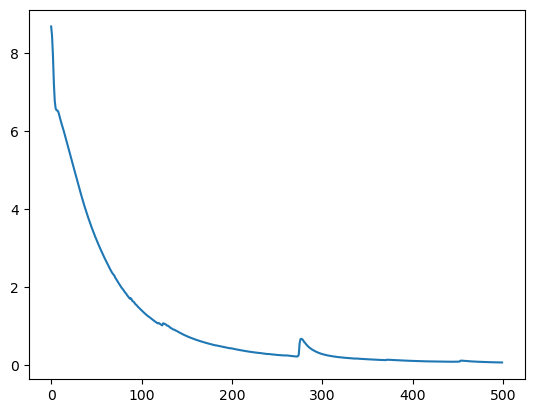

In [51]:
lista_tensor = torch.tensor( lista_loss ) 
plot.plot( lista_tensor )

In [56]:
posicao = random.randint(0, len(frases_selecionadas))
frase = frases_selecionadas[posicao]
print(f"Posicao: {posicao}")
print(f"Frase: {frase}")

Posicao: 817
Frase: apenas algumas palavras é uma coisa boa george a romero ainda está entre nós porque se ele estivesse morto ele seria forçado a se levantar do túmulo para votar contra as pessoas que fizeram essa sátira política e o mais triste de tudo é que eu realmente concordar com os sentimentos dessas pessoas sim há zumbis e eles têm uma boa razão para voltar do além para votar ah e um deles acaba com o doctor da startrek voyager isso é tão assustador quanto pode ser pessoas se você está procurando um filme de terror sugiro que continue procurando e se você está procurando uma sátira política espirituosa você também está no lugar errado e não apenas porque essa série é chamada de mestres do horror mas não me deixe te segurar talvez você veja algo que eu perdi embora as chances são que você estará perdendo seu tempo com isso assim como eu tenho vamos apenas dizer que eu prefiro meus filmes de zumbis com os zumbis em pé na frente da câmera


In [53]:
# frase = "puxa a disciplina de processamento de linguagem natural é complicada"

In [57]:
# Tokeninzar e codificar a frase
unknown = dicionario["<UNKNOWN>"]
tokens = frase.split(" ")
lista_tokenizada = []
for token in tokens:
    lista_tokenizada.append(dicionario.get( token, unknown ))


valor_pad = dicionario["<PAD>"]
lista_padded = padding(lista_tokenizada[0:10], MAIOR_FRASE, valor_pad)
print(lista_padded)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 243, 322, 1191, 30, 3, 108, 1335, 2307, 35, 5095]


In [58]:
X_predict = torch.tensor(lista_padded)
Y_predict = modelo( X_predict )
pos_token = torch.argmax(Y_predict)
print("Frase parcial: ", " ".join(tokens[0:8]))
print("Tamanho Y_predict: ", len(Y_predict))
print("Token encontrado: ", pos_token)
palavra_encontrada = encoder.inverse_transform( [pos_token.item()] )
print("Palavra encontrada: ", palavra_encontrada)
print("Frase completa: ", " ".join(tokens[0:8]) + " " + palavra_encontrada)

Frase parcial:  apenas algumas palavras é uma coisa boa george
Tamanho Y_predict:  5673
Token encontrado:  tensor(4749)
Palavra encontrada:  ['se']
Frase completa:  ['apenas algumas palavras é uma coisa boa george se']
